In [56]:
import pandas as pd
import numpy

df = pd.read_csv("prices_round_1_day_-1.csv", sep=';')

In [57]:
PEPPER_TIMESTAMP_COEF = 0.001000006003413

In [58]:
df['fp'] = 1e4 + 1e3 + df['timestamp'] * PEPPER_TIMESTAMP_COEF

In [59]:
filtered_df = df[(df["bid_price_1"] > df["fp"]) | (df["bid_price_2"] > df["fp"])]
len(filtered_df)

169

In [60]:
filtered_df['fp+slope+s/2'] = filtered_df['fp'] + PEPPER_TIMESTAMP_COEF + 8

/tmp/ipykernel_11760/1291364793.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['fp+slope+s/2'] = filtered_df['fp'] + PEPPER_TIMESTAMP_COEF + 8


In [61]:
filtered_df["signal"] = (filtered_df['bid_price_2'] - filtered_df['fp+slope+s/2']) > PEPPER_TIMESTAMP_COEF

/tmp/ipykernel_11760/3718647503.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df["signal"] = (filtered_df['bid_price_2'] - filtered_df['fp+slope+s/2']) > PEPPER_TIMESTAMP_COEF


In [62]:
len(filtered_df[filtered_df['signal']])

0

In [63]:
filtered_df.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,fp,fp+slope+s/2,signal
516,-1,25800,INTARIAN_PEPPER_ROOT,11029.0,3.0,11020.0,9.0,NaN,NaN,11032.0,9.0,11035.0,16.0,NaN,NaN,11030.5,0.0,11025.800155,11033.801155,False
532,-1,26600,INTARIAN_PEPPER_ROOT,11029.0,8.0,11018.0,19.0,NaN,NaN,11033.0,10.0,11035.0,19.0,NaN,NaN,11031.0,0.0,11026.600160,11034.601160,False
604,-1,30200,INTARIAN_PEPPER_ROOT,11033.0,3.0,11024.0,10.0,11021.0,20.0,11036.0,10.0,11039.0,20.0,NaN,NaN,11034.5,0.0,11030.200181,11038.201181,False
632,-1,31600,INTARIAN_PEPPER_ROOT,11034.0,3.0,11026.0,10.0,NaN,NaN,11038.0,10.0,11040.0,19.0,NaN,NaN,11036.0,0.0,11031.600190,11039.601190,False
701,-1,35000,INTARIAN_PEPPER_ROOT,11038.0,8.0,11029.0,10.0,11026.0,25.0,11041.0,10.0,11044.0,25.0,NaN,NaN,11039.5,0.0,11035.000210,11043.001210,False


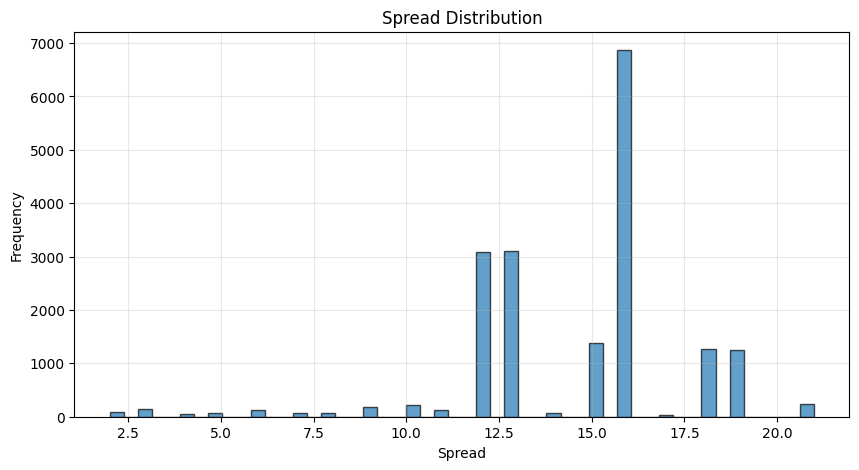

In [64]:
import matplotlib.pyplot as plt

spread = (df["ask_price_1"] - df["bid_price_1"]).dropna()

plt.figure(figsize=(10, 5))
plt.hist(spread, bins=50, edgecolor="black", alpha=0.7)
plt.xlabel("Spread")
plt.ylabel("Frequency")
plt.title("Spread Distribution")
plt.grid(True, alpha=0.3)
plt.show()


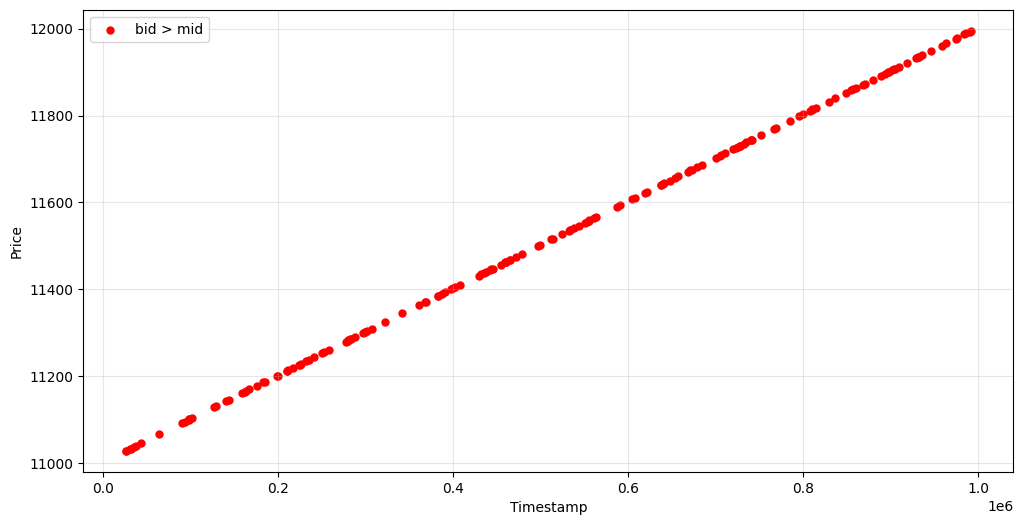

In [65]:
import matplotlib.pyplot as plt

mid_plot_df = df[df["mid_price"].notna() & (df["mid_price"] != 0)]

plt.figure(figsize=(12, 6))
# plt.plot(mid_plot_df["timestamp"], mid_plot_df["mid_price"], label="Mid Price", linewidth=1.5)
# plt.plot(df["timestamp"], df["bid_price_1"], label="Bid Price", linewidth=1.2, alpha=0.8)

plt.scatter(
    filtered_df["timestamp"],
    filtered_df["bid_price_1"],
    color="red",
    s=25,
    label="bid > mid"
)

plt.xlabel("Timestamp")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
